In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylabdd as dd
print(dd.FORT_AVAIL)

True


In [51]:
def force(yp, by, tau0, B, C, Nc, gbdx):
    fdis = np.zeros_like(yp)
    for j, yj in enumerate(yp):
        hh = 0.
        for i, yi in enumerate(yp):
            if i==j:
                continue
            hh += B/(yj - yi)
        for i, bi in enumerate(by):
            xi = np.abs(i-Nc)*gbdx
            hh += bi/(yj-xi)
        fdis[j] = (C*hh - tau0)*B
    return fdis
        

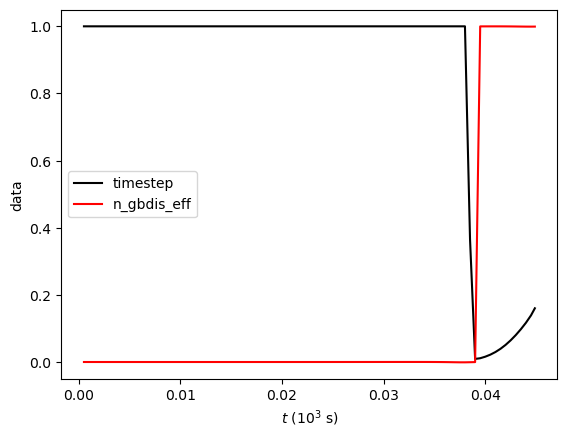

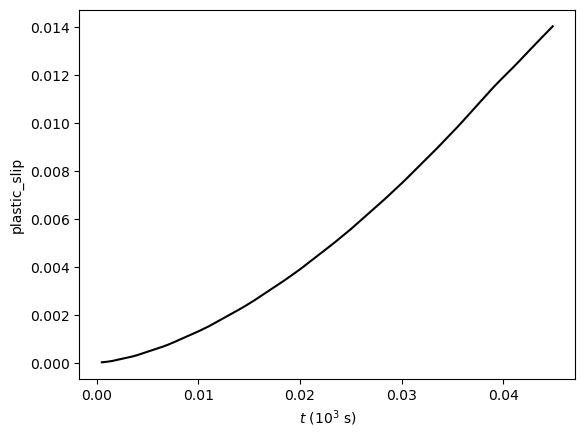

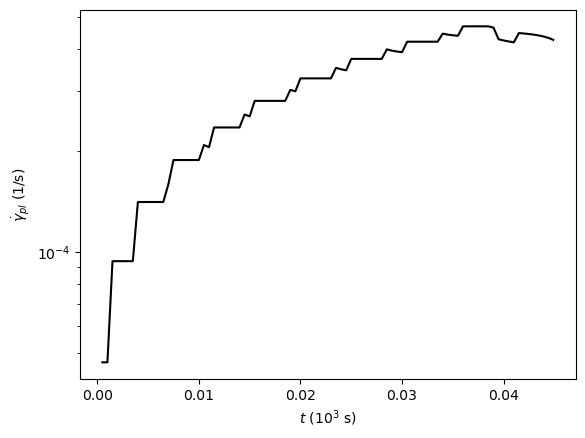

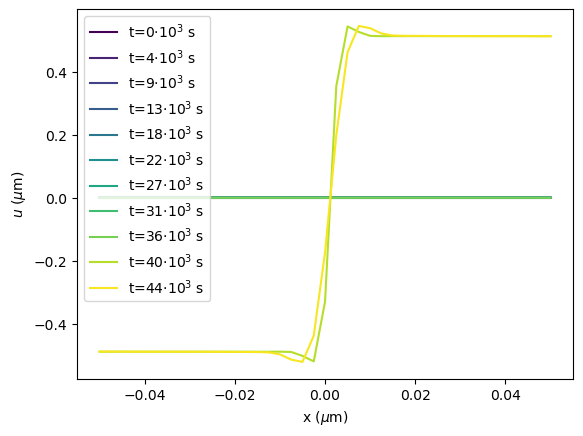

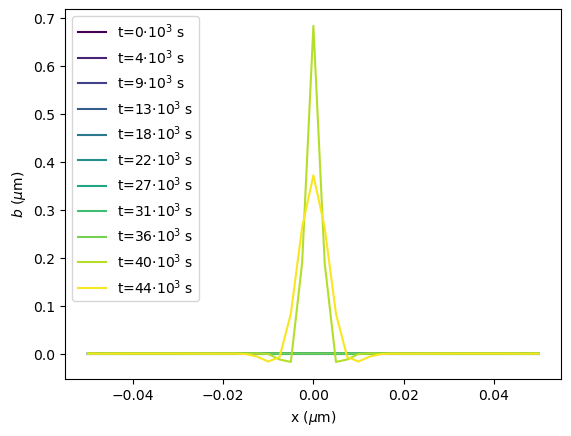

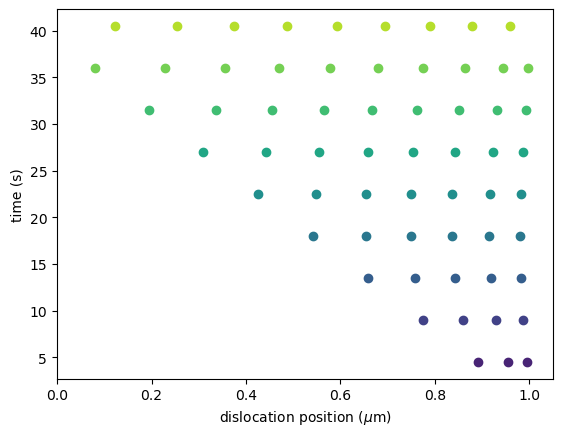

In [54]:
gbdd = dd.GB_dislocations(from_file="../examples/gbdd/test_tau150_T500.h5")
gbdd.plot_time_series(['timestep', 'n_gbdis_eff'])
gbdd.plot_time_series("plastic_slip")
gbdd.plot_time_series("plast_slip_rate")
gbdd.plot_field('displacement')
gbdd.plot_field('bfield')  # , file="T900_Lgb10_short.pdf")
gbdd.plot_pile_up()
                          

In [67]:
it = 79
sp_ang = 0.5*np.pi
C = gbdd.mu*gbdd.B/(2*np.pi*(1.-gbdd.nu))   # Constant for dislocation stress field
hh = gbdd.pu_dis['position'][it, :]
ind = np.nonzero(hh)[0]
npu = len(ind)
ngbn = gbdd.Ngbn
Nc = int((ngbn+1)/2) - 1
gbdx = gbdd.Dgp/(ngbn-1)
ndis = npu + ngbn
xp = np.zeros(ndis)
yp = np.zeros(ndis)
by = np.ones(ndis)
yp[0:npu] = hh[ind]  # positions of pile-up dislocations stored in first section of array, GB is at y=0
xp[0:npu] = np.ones(npu)*gbdd.Dgp*0.5  # x-positions of pile-up dislocations
xp[npu:] = gbdd.gb_node_pos + gbdd.Dgp*0.5
by[npu:] = gbdd.field_data['bfield'][it, :]  #np.zeros(ngbn) #
gbf = gbdd.pu_dis['force'][it, ind]

#define different dislocations in box
# initialze object of class Dislocations
dsl = dd.Dislocations(ndis, npu, sp_ang, C, gbdd.B,
                      xpos=xp, ypos=yp, LX=gbdd.Dgp, LY=gbdd.D2,  #LX=50000, LY=50000, #
                      bc="fixed")
dsl.by = by
#dsl.plot_stress(show_arrows=False)
fpk = dsl.calc_force(tau0=-gbdd.tau0)
#fdis = force(yp[:npu], by[npu:]*gbdd.B, gbdd.tau0, gbdd.B, C/gbdd.B, Nc, gbdx)
print(by)
print(yp[:npu])
print(fpk[1, :])
print(gbf)
#print(fdis)
print(f"Rel. error in leading dislocation: {fpk[1, 0]/gbf[0]-1}")
print(f"Average rel. error in pile-up: {np.sum(np.abs(fpk[1, :npu]/gbf[:npu]-1))/npu}")

[ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  0.00000000e+00 -1.63220258e-06 -9.31321066e-05
 -2.01453463e-05  1.19852502e-05  8.66488322e-06  5.01491767e-06
  5.62610123e-06  7.63493116e-06  1.00774512e-05  1.33265286e-05
  1.82529774e-05  2.65329954e-05  4.23136758e-05  8.10390936e-05
  2.34261160e-04  7.82519756e-04 -9.86665509e-04 -2.34220908e-02
  5.23082017e-02  9.41732124e-01  5.23082017e-02 -2.34220908e-02
 -9.86665509e-04  7.82519756e-04  2.34261160e-04  8.10390936e-05
  4.23136758e-05  2.65329954e-05  1.82529774e-05  1.33265286e-05
  1.00774512e-05  7.63493116e-06  5.62610123e-06  5.01491767e-06
  8.66488322e-06  1.19852502e-05 -2.01453463e-05 -9.31321066e-05
 -1.63220258e-06  0.00000000e+00]
[0.14527254 0.27591775 0.39504524 0.50663556 0.61235866 0.71272733
 0.80735434 0.89465127 0.97082043]
[-0.04719254 -0.04478374 -0.04246803 -0.04020822 -0.03788607 -0.03532509
 -0.0321824

In [56]:
gbdd.nout

np.int64(91)

In [ ]:
N = 100
res = []
for i in range(N):
    xp = np.random.rand(2)*5
    yp = np.random.rand(2)*5
    sp = np.random.rand(1)[0]*np.pi*.5
    df = dd.Dislocations(2, 2, sp, C, gbdd.B,
                          xpos=xp, ypos=yp, LX=5, LY=5,
                          bc="fixed")
    dp = dd.Dislocations(2, 2, sp, C, gbdd.B,
                          xpos=xp, ypos=yp, LX=50000, LY=50000,
                          bc="pbc")
    res.append(df.calc_force(tau0=0) / dp.calc_force(tau0=0) - 1)
    #print(dp.xpos, dp.ypos)
    #print(dp.bx, dp.by)
    #print(res[i])
print(np.max(np.abs(res)))


In [ ]:
mu = 80.0e3          # shear modulus
nu = 0.3             # Poisson ratio
b0 = 0.2e-3          # Burgers vector norm
C = mu*b0/(2*np.pi*(1.-nu))   # Constant for dislocation stress field
f0 = 10.             # initial slip resistance

#define box 
LX = LY = 10.

#define different dislocations in box
dsl10 = dd.Dislocations(1, 0, 0., C, b0, xpos=LX/2, ypos=LY/2, LX=LX, LY=LY)  # initialze object of class Dislocations
dsl10.plot_stress()             # plot elastic fields

dsl01 = dd.Dislocations(1, 0, 90.*np.pi/180., C, b0, xpos=LX/2, ypos=LY/2, LX=LX, LY=LY)  # initialze object of class Dislocations
dsl01.plot_stress()             # plot elastic fields

dsl11 = dd.Dislocations(1, 0, 45.*np.pi/180., C, b0, xpos=LX/2, ypos=LY/2, LX=LX, LY=LY)  # initialze object of class Dislocations
dsl11.plot_stress()             # plot elastic fields